In [1]:
library(ggplot2)
library(dplyr)
library(plotly)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘plotly’


The following object is masked from ‘package:ggplot2’:

    last_plot


The following object is masked from ‘package:stats’:

    filter


The following object is masked from ‘package:graphics’:

    layout




In [2]:
# Load hit calling summary
hit_df <- readr::read_csv(file.path("inference_results", "hit_call_table.csv"))

print(dim(hit_df))

head(hit_df)

Rows: 551 Columns: 8
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (2): Metadata_treatment, Pathway
dbl (5): mean_logit_score, mean_relative_cell_count, mean_average_precision,...
lgl (1): hit

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


[1] 551   8


Metadata_treatment,Pathway,mean_logit_score,mean_relative_cell_count,mean_average_precision,corrected_p_value,-log10(p-value),hit
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
UCD-0001812,Others,0.9779592,0.8115532,1.0000000,0.002764107,2.558445,TRUE
UCD-0159487,Others,0.9594374,0.8163263,0.6805556,0.048928447,1.310439,TRUE
UCD-0159486,Others,0.9446008,0.9049643,0.7458333,0.040347712,1.394181,TRUE
UCD-0159268,Others,0.9610885,0.9960657,1.0000000,0.002764107,2.558445,TRUE
UCD-0001419,Transmembrane Transporters,0.9917530,0.8965338,0.7236532,0.041758242,1.379258,TRUE
UCD-0001921,Epigenetics,0.9697368,0.8184931,1.0000000,0.002764107,2.558445,TRUE


In [3]:
# Setting hit tresholds
map_threshold <- -log10(0.05)
logit_threshold <- 0.9
cell_count_threshold <- 0.8

Warning message:
“Removed 101 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 101 rows containing missing values or values outside the scale range
(`geom_point()`).”


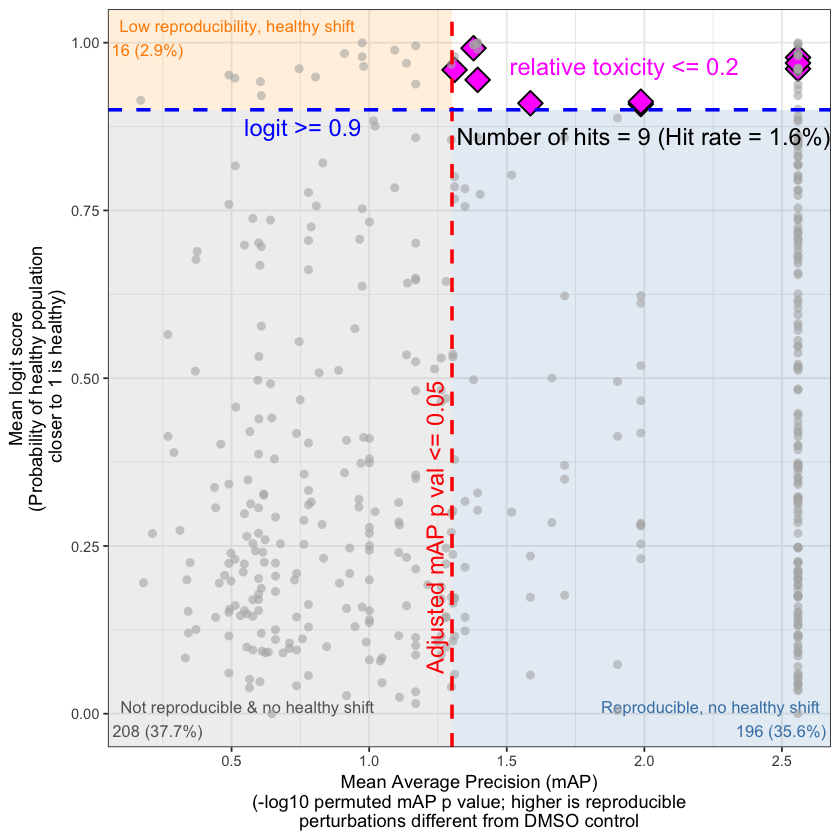

In [4]:
n_hits <- sum(hit_df$`-log10(p-value)` >= map_threshold & hit_df$mean_logit_score >= logit_threshold & hit_df$mean_relative_cell_count >= 0.8, na.rm = TRUE)
hit_rate <- round(n_hits / nrow(hit_df) * 100, 1)

n_total <- nrow(hit_df)
n_ll <- sum(hit_df$`-log10(p-value)` < map_threshold & hit_df$mean_logit_score < logit_threshold, na.rm = TRUE)
n_lr <- sum(hit_df$`-log10(p-value)` >= map_threshold & hit_df$mean_logit_score < logit_threshold, na.rm = TRUE)
n_tl <- sum(hit_df$`-log10(p-value)` < map_threshold & hit_df$mean_logit_score >= logit_threshold, na.rm = TRUE)

pct <- function(n) paste0(n, " (", round(n / n_total * 100, 1), "%)")

(
    ggplot(
        hit_df |> dplyr::mutate(significant = `-log10(p-value)` >= map_threshold & mean_logit_score >= logit_threshold & mean_relative_cell_count >= 0.8),
        aes(x = `-log10(p-value)`, y = mean_logit_score,
            color = significant, fill = significant, alpha = significant,
            shape = significant, size = significant)
    )
    + annotate("rect", xmin = -Inf, xmax = map_threshold, ymin = -Inf, ymax = logit_threshold,
               fill = "grey80", alpha = 0.3)
    + annotate("rect", xmin = map_threshold, xmax = Inf, ymin = -Inf, ymax = logit_threshold,
               fill = "steelblue", alpha = 0.15)
    + annotate("rect", xmin = -Inf, xmax = map_threshold, ymin = logit_threshold, ymax = Inf,
               fill = "orange", alpha = 0.15)
    + annotate("text", x = -Inf, y = -Inf,
               label = paste0("Not reproducible & no healthy shift\n", pct(n_ll)),
               hjust = -0.05, vjust = -0.3, size = 3.5, color = "grey40")
    + annotate("text", x = Inf, y = -Inf,
               label = paste0("Reproducible, no healthy shift\n", pct(n_lr)),
               hjust = 1.05, vjust = -0.3, size = 3.5, color = "steelblue")
    + annotate("text", x = -Inf, y = Inf,
               label = paste0("Low reproducibility, healthy shift\n", pct(n_tl)),
               hjust = -0.05, vjust = 1.3, size = 3.5, color = "darkorange")
    + geom_point(stroke = 0.8)
    + theme_bw()
    + scale_color_manual(values = c("TRUE" = "black", "FALSE" = "grey70"), guide = "none")
    + scale_fill_manual(values = c("TRUE" = "magenta", "FALSE" = "grey70"), guide = "none")
    + scale_alpha_manual(values = c("TRUE" = 1, "FALSE" = 0.6), guide = "none")
    + scale_shape_manual(values = c("TRUE" = 23, "FALSE" = 16), guide = "none")
    + scale_size_manual(values = c("TRUE" = 5, "FALSE" = 2), guide = "none")
    + xlab("Mean Average Precision (mAP)\n(-log10 permuted mAP p value; higher is reproducible\nperturbations different from DMSO control")
    + ylab("Mean logit score\n(Probability of healthy population\n closer to 1 is healthy)")
    + geom_vline(xintercept = map_threshold, linetype = "dashed", color = "red", lwd = 1)
    + geom_hline(yintercept = logit_threshold, linetype = "dashed", color = "blue", lwd = 1)
    + annotate("text", x = map_threshold, y = -Inf,
               label = "Adjusted mAP p val <= 0.05",
               color = "red", hjust = -0.25, vjust = -0.5, angle = 90, size = 5)
    + annotate("text", x = Inf, y = logit_threshold, label = paste0("logit >= ", logit_threshold),
               color = "blue", hjust = 5, vjust = 1.5, size = 5)
    + annotate("text", x = Inf, y = 0.75, label = "relative toxicity <= 0.2",
               color = "magenta", hjust = 1.4, vjust = -8, size = 5)
    + annotate("text", x = Inf, y = Inf, label = paste0("Number of hits = ", n_hits, " (Hit rate = ", hit_rate, "%)"),
               hjust = 1, vjust = 8, size = 5)
    + theme(legend.position = "none")
)

ggsave("hit_calling_2d.png", dpi = 300, width = 8, height = 6)

In [5]:
plot_hit_df <- hit_df |> dplyr::mutate(significant = `-log10(p-value)` >= map_threshold & mean_logit_score >= logit_threshold & mean_relative_cell_count >= 0.8)

x_range <- range(hit_df$`-log10(p-value)`, na.rm = TRUE)
y_range <- range(hit_df$mean_relative_cell_count, na.rm = TRUE)
z_range <- range(hit_df$mean_logit_score, na.rm = TRUE)

hit_df <- hit_df |> dplyr::mutate(significant = `-log10(p-value)` >= map_threshold & mean_logit_score >= logit_threshold & mean_relative_cell_count >= 0.8)



In [6]:
p <- plot_ly() |>
    add_trace(
        data = plot_hit_df |> dplyr::filter(!significant),
        x = ~`-log10(p-value)`,
        y = ~mean_logit_score,
        z = ~mean_relative_cell_count,
        type = "scatter3d",
        mode = "markers",
        marker = list(size = 5, color = "grey70", opacity = 0.6, line = list(color = "black", width = 1)),
        text = ~paste0("Compound: ", Metadata_treatment, "<br>Pathway: ", Pathway),
        hoverinfo = "text+x+y+z",
        name = "non-hit"
    ) |>
    add_trace(
        data = plot_hit_df |> dplyr::filter(significant),
        x = ~`-log10(p-value)`,
        y = ~mean_logit_score,
        z = ~mean_relative_cell_count,
        type = "scatter3d",
        mode = "markers",
        marker = list(size = 8, color = "magenta", symbol = "diamond", line = list(color = "black", width = 1)),
        text = ~paste0("Compound: ", Metadata_treatment, "<br>Pathway: ", Pathway),
        hoverinfo = "text+x+y+z",
        name = "hit"
    ) |>
    add_trace(
        type = "mesh3d",
        x = c(map_threshold, map_threshold, map_threshold, map_threshold),
        z = c(y_range[1], y_range[2], y_range[2], y_range[1]),
        y = c(z_range[1], z_range[1], z_range[2], z_range[2]),
        i = c(0, 0), j = c(1, 2), k = c(2, 3),
        facecolor = c("red", "red"),
        opacity = 0.2, showlegend = TRUE,
        name = "Adjusted mAP p val <= 0.05"
    ) |>
    add_trace(
        type = "mesh3d",
        x = c(x_range[1], x_range[2], x_range[2], x_range[1]),
        z = c(y_range[1], y_range[1], y_range[2], y_range[2]),
        y = c(logit_threshold, logit_threshold, logit_threshold, logit_threshold),
        i = c(0, 0), j = c(1, 2), k = c(2, 3),
        facecolor = c("blue", "blue"),
        opacity = 0.2, showlegend = TRUE,
        name = paste0("logit >= ", logit_threshold)
    ) |>
    add_trace(
        type = "mesh3d",
        x = c(x_range[1], x_range[2], x_range[2], x_range[1]),
        z = c(0.8, 0.8, 0.8, 0.8),
        y = c(z_range[1], z_range[1], z_range[2], z_range[2]),
        i = c(0, 0), j = c(1, 2), k = c(2, 3),
        facecolor = c("magenta", "magenta"),
        opacity = 0.2, showlegend = TRUE,
        name = "relative toxicity >= 0.8"
    ) |>
    layout(
        scene = list(
xaxis = list(title = "Mean Average Precision (mAP)<br>(-log10 permuted mAP p value; higher is reproducible<br>perturbations different from DMSO control"),
zaxis = list(title = "Relative cell count<br>(Lower values higher toxicity)"),
yaxis = list(title = "Mean logit score<br>(Probability of healthy population<br>closer to 1 is healthy)")
        )
    )


In [7]:
htmlwidgets::saveWidget(p, "hit_calling_3d.html", selfcontained = TRUE)

Warning message:
“Ignoring 24 observations”
